# Detecção de Anomalias em Transações Financeiras

Projeto de análise exploratória utilizando um dataset de transações financeiras com foco na identificação de padrões relacionados a possíveis fraudes.

O objetivo deste estudo é compreender a estrutura dos dados, identificar características relevantes das transações e avaliar o impacto do desbalanceamento das classes em problemas de detecção de fraude.

## Importação das Bibliotecas

Nesta etapa serão importadas as bibliotecas necessárias para manipulação dos dados, realização de cálculos matemáticos e construção de visualizações gráficas.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carregamento do Dataset

O dataset utilizado contém registros anonimizados de transações financeiras. O objetivo inicial é carregar os dados para posterior exploração e análise.

In [107]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Estrutura do Dataset

Nesta etapa será realizada uma inspeção geral da base de dados para identificar quantidade de registros, tipos de dados e possíveis valores ausentes.

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Estatísticas Descritivas

As estatísticas descritivas permitem compreender a distribuição dos dados, identificando medidas como média, desvio padrão, valores mínimos e máximos.

In [109]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Distribuição das Classes

A coluna Class representa a variável alvo do problema.

- Class = 0 → Transação normal
- Class = 1 → Transação fraudulenta

A análise da distribuição das classes permite identificar possíveis problemas de desbalanceamento.

In [110]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


## Percentual de Fraudes na Base de Dados

Nesta etapa será calculado o percentual de transações fraudulentas presentes no dataset.

Essa métrica permite compreender a proporção entre transações normais e fraudulentas, evidenciando o nível de desbalanceamento das classes. Em problemas de detecção de fraude, normalmente existe uma quantidade muito pequena de registros fraudulentos quando comparada às transações legítimas.

O resultado será apresentado em percentual para facilitar a interpretação.

In [111]:
# Calcula o percentual de transações fraudulentas

fraudes = df['Class'].mean() * 100

print(f"Percentual de fraudes na base: {fraudes:.4f}%")

Percentual de fraudes na base: 0.1727%


## Visualização da Distribuição das Classes

A representação gráfica facilita a identificação visual do desbalanceamento entre transações normais e fraudulentas presentes no dataset.

Espera-se observar uma predominância significativa das transações normais em relação às transações classificadas como fraude.

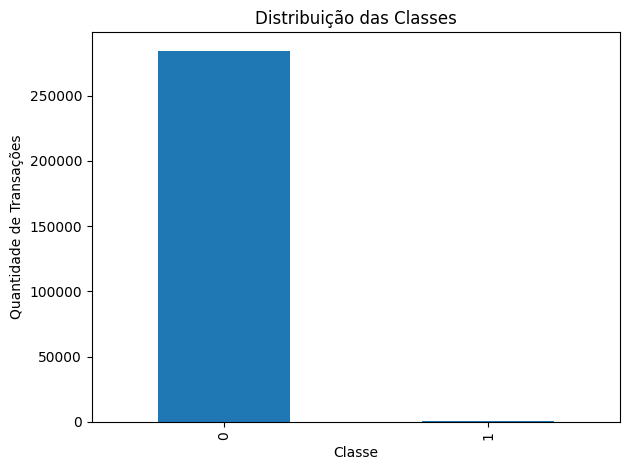

In [112]:
# Cria o gráfico de distribuição das classes

df['Class'].value_counts().plot(kind='bar')

plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Transações')

# Ajusta automaticamente o espaçamento dos elementos do gráfico
plt.tight_layout()

plt.show()

## Transformação Logarítmica da Variável Amount

A variável Amount apresenta grande variação entre os valores das transações.

Para reduzir a assimetria dos dados e facilitar futuras análises, será aplicada uma transformação logarítmica.

In [113]:
df['Amount_log'] = np.log1p(df['Amount'])

df[['Amount', 'Amount_log']].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


## Comparação entre Transações Normais e Fraudes

Nesta etapa serão separados os registros normais e fraudulentos para comparação básica dos dados.

In [114]:
transacoes_normais = df[df['Class'] == 0]

fraudes = df[df['Class'] == 1]

print("Transações normais:", len(transacoes_normais))
print("Fraudes:", len(fraudes))

Transações normais: 284315
Fraudes: 492


## Comparação dos Valores Médios das Transações

Além da análise da quantidade de registros, é interessante comparar o valor médio das transações normais e fraudulentas.

Essa avaliação permite identificar possíveis diferenças de comportamento entre os grupos analisados, fornecendo indícios iniciais sobre características que podem estar associadas às ocorrências de fraude.

Embora essa análise isoladamente não seja suficiente para identificar padrões definitivos, ela contribui para a compreensão do perfil das transações presentes na base de dados.

In [115]:
print("Valor médio das transações normais:")
print(transacoes_normais['Amount'].mean())

print("\nValor médio das fraudes:")
print(fraudes['Amount'].mean())

Valor médio das transações normais:
88.29102242231328

Valor médio das fraudes:
122.21132113821139


## Conclusão

A análise exploratória permitiu compreender a estrutura do dataset e identificar características importantes relacionadas ao problema de detecção de fraudes em transações financeiras.

Os resultados demonstraram um forte desbalanceamento entre as classes, com aproximadamente 99,8% das transações classificadas como normais e apenas uma pequena parcela identificada como fraude.

Também foi possível realizar análises estatísticas básicas, visualizar a distribuição das classes, aplicar uma transformação logarítmica na variável Amount e comparar características iniciais entre transações normais e fraudulentas.

Este estudo representa uma etapa inicial para futuras aplicações de técnicas de Machine Learning voltadas à detecção de anomalias, servindo como base para o desenvolvimento de modelos preditivos mais avançados.